## ASTraM Event Forecasting - Model Training

This notebook engineers historical rolling features, performs a time-based walk-forward split, and trains the Duration Regression and Closure Probability models.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, median_absolute_error, roc_auc_score, brier_score_loss
from sklearn.preprocessing import LabelEncoder
import shap
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models', exist_ok=True)

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/augmented_astram_events.csv')
df['start_datetime'] = pd.to_datetime(df['start_datetime'])
df = df.dropna(subset=['start_datetime'])
df = df.sort_values('start_datetime').reset_index(drop=True)
print(f"Loaded shape: {df.shape}")

Loaded shape: (7006, 48)


## 2. Feature Engineering
We extract hour, day of week, and create rolling incident counts.

In [3]:
df['hour'] = df['start_datetime'].dt.hour
df['dayofweek'] = df['start_datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# Ensure corridor has no NAs before grouping, else groupby drops them and row counts mismatch
df['corridor'] = df['corridor'].fillna('Unknown')

# Rolling counts on corridor
df_temp = df.set_index('start_datetime')
# Keep dropna=False so that NaN groups are kept, though we just filled them
rolling_1d = df_temp.groupby('corridor', dropna=False).rolling('1D')['id'].count().reset_index(name='count_1d')
rolling_7d = df_temp.groupby('corridor', dropna=False).rolling('7D')['id'].count().reset_index(name='count_7d')
rolling_30d = df_temp.groupby('corridor', dropna=False).rolling('30D')['id'].count().reset_index(name='count_30d')

df['corridor_count_1d'] = rolling_1d['count_1d'].values - 1 # Exclude current incident
df['corridor_count_7d'] = rolling_7d['count_7d'].values - 1
df['corridor_count_30d'] = rolling_30d['count_30d'].values - 1

# Create Severity bucket
def get_severity(row):
    if row['priority'] == 'High' and row['requires_road_closure'] == True:
        return 2 # High
    elif row['priority'] == 'High':
        return 1 # Medium
    return 0 # Low
df['severity_score'] = df.apply(get_severity, axis=1)

## 3. Time-Based Walk-Forward Split
We split the data by time to prevent future leakage. E.g., train on first 80% chronologically, test on last 20%.

In [4]:
split_idx = int(len(df) * 0.8)
train_df_full = df.iloc[:split_idx].copy()
test_df_full = df.iloc[split_idx:].copy()

print(f"Train dates: {train_df_full['start_datetime'].min()} to {train_df_full['start_datetime'].max()}")
print(f"Test dates: {test_df_full['start_datetime'].min()} to {test_df_full['start_datetime'].max()}")

Train dates: 2023-11-10 00:54:48.154000+05:30 to 2024-03-13 10:50:55.448000+05:30
Test dates: 2024-03-13 10:52:56.176000+05:30 to 2024-04-08 22:41:42.780000+05:30


## 4. Modeling Setup

In [5]:
features = [
    'event_cause', 'corridor', 'priority', 
    'hour', 'dayofweek', 'is_weekend',
    'corridor_count_1d', 'corridor_count_7d', 'corridor_count_30d',
    'precipitation_mm',
    'osm_highway_class', 'osm_lanes', 'dist_to_nearest_road_m'
]

categorical_features = ['event_cause', 'corridor', 'priority', 'osm_highway_class']

# Fill NAs in categoricals
for col in categorical_features:
    train_df_full[col] = train_df_full[col].fillna('Unknown')
    test_df_full[col] = test_df_full[col].fillna('Unknown')

# Fill NAs in continuous/numeric OSM features
train_df_full['osm_lanes'] = train_df_full['osm_lanes'].fillna(2.0)
test_df_full['osm_lanes'] = test_df_full['osm_lanes'].fillna(2.0)

# Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit on all possible values to avoid unseen labels in test
    le.fit(pd.concat([train_df_full[col], test_df_full[col]]))
    train_df_full[col] = le.transform(train_df_full[col])
    test_df_full[col] = le.transform(test_df_full[col])
    label_encoders[col] = le

# Save encoders for app
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

## 5. Closure Probability Model
Trained on the **FULL** dataset since `requires_road_closure` is well-populated.

In [6]:
X_train_closure = train_df_full[features]
y_train_closure = train_df_full['requires_road_closure'].astype(int)
X_test_closure = test_df_full[features]
y_test_closure = test_df_full['requires_road_closure'].astype(int)

closure_model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
closure_model.fit(X_train_closure, y_train_closure)

preds_proba = closure_model.predict_proba(X_test_closure)[:, 1]
auc = roc_auc_score(y_test_closure, preds_proba)
brier = brier_score_loss(y_test_closure, preds_proba)

print(f"Closure Model AUC: {auc:.4f}")
print(f"Closure Model Brier Score: {brier:.4f}")

closure_model.save_model('../models/closure_model.json')

Closure Model AUC: 0.7682
Closure Model Brier Score: 0.0556


## 6. Duration Regression Model
Trained **ONLY** on the subset with valid duration labels.

In [7]:
train_df_dur = train_df_full.dropna(subset=['duration_minutes']).copy()
test_df_dur = test_df_full.dropna(subset=['duration_minutes']).copy()

X_train_dur = train_df_dur[features]
y_train_dur = np.log1p(train_df_dur['duration_minutes'])
X_test_dur = test_df_dur[features]
y_test_dur = test_df_dur['duration_minutes'] # Keep actuals for metric evaluation

duration_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
duration_model.fit(X_train_dur, y_train_dur)

# Predict and convert back from log space
preds_log = duration_model.predict(X_test_dur)
preds_minutes = np.expm1(preds_log)

mae = mean_absolute_error(y_test_dur, preds_minutes)
med_ae = median_absolute_error(y_test_dur, preds_minutes)

print(f"Duration Model MAE: {mae:.2f} minutes")
print(f"Duration Model Median AE: {med_ae:.2f} minutes")

duration_model.save_model('../models/duration_model.json')

Duration Model MAE: 585.46 minutes
Duration Model Median AE: 95.62 minutes


## 7. SHAP Explainability

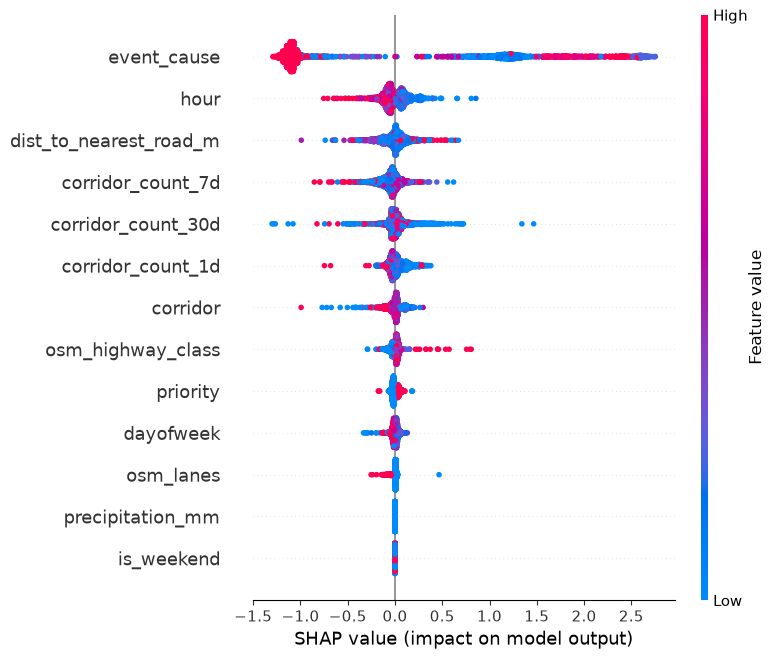

In [8]:
explainer = shap.TreeExplainer(duration_model)
shap_values = explainer.shap_values(X_train_dur)
shap.summary_plot(shap_values, X_train_dur, feature_names=features)